# Workflow Fundamentals of PyTorch

## Imports

In [1]:
import torch
import matplotlib.pyplot as plt
from pathlib import Path

In [2]:
device = "cuda" if torch.cuda.is_available() else "cpu"

print(device)

cuda


## Linear Regression

### Preparing Data

In [3]:
torch.manual_seed(42)

# Generate a "Answer in a line" -> 2x + 5:

sample_size = 1000

answer = torch.arange(sample_size, device=device).float() * 2 + 5

# generate some noisy data to have some fun:

noise = torch.empty_like(answer).uniform_(0.9, 1.1)
data = answer * noise

y = data.unsqueeze(dim = 1)
x = torch.arange(sample_size, device=device).unsqueeze(dim = 1).float()

In [4]:
print(f"X: {type(x)} , {x.shape}")
print(f"Y: {type(y)} , {y.shape}")

X: <class 'torch.Tensor'> , torch.Size([1000, 1])
Y: <class 'torch.Tensor'> , torch.Size([1000, 1])


In [5]:
x[:5], y[:5]

(tensor([[0.],
         [1.],
         [2.],
         [3.],
         [4.]], device='cuda:0'),
 tensor([[ 5.1130],
         [ 6.3141],
         [ 8.8171],
         [ 9.9887],
         [12.1063]], device='cuda:0'))

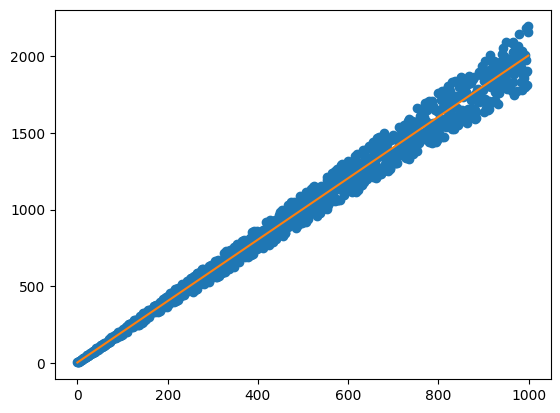

In [6]:
# plt.Figure(8, 8)
plt.plot(y[:, 0].cpu(), 'o')
plt.plot(answer.cpu())
plt.show()

In [7]:
# train test split

train_split = int(0.8 * len(x))

x_train, y_train = x[:train_split], y[:train_split]
x_test, y_test = x[train_split:], y[train_split:]

len(x_train), len(y_train), len(x_test), len(y_test)

(800, 800, 200, 200)

In [8]:
# Normalization:

x_mean, x_std = x_train.mean(), x_train.std()
y_mean, y_std = y_train.mean(), y_train.std()

x_train_n = (x_train - x_mean) / x_std
x_test_n  = (x_test  - x_mean) / x_std
y_train_n = (y_train - y_mean) / y_std
y_test_n  = (y_test  - y_mean) / y_std

### Building Model

In [9]:
class LinearRegressionModel(torch.nn.Module):
    def __init__(self):
        super().__init__()
        
        self.weights = torch.nn.Parameter(torch.randn(1, device=device))
        self.bias = torch.nn.Parameter(torch.randn(1, device=device))

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.weights * x + self.bias

#### `torch.nn`

Contains all of the building blocks for computational graphs.

#### `torch.nn.Parameter`

Stores tensors that can be used with nn.Module. 
If `requires_grad=True` gradients are calculated automatically, this is often referred to as "autograd".

#### `torch.nn.Module`

The base class for all neural network modules, all the building blocks for neural networks are subclasses. 
If you're building a neural network in PyTorch, your models should subclass nn.Module. 
Requires a forward() method be implemented.

#### `torch.optim`

Contains various optimization algorithms.
(these tell the model parameters stored in nn.Parameter how to best change to improve gradient descent and in turn reduce the loss).

#### `def forward()`

Defines the computation that will take place on the data passed to the particular nn.Module (e.g. the linear regression formula above).

In [10]:
torch.manual_seed(42)

model = LinearRegressionModel()

list(model.parameters())

[Parameter containing:
 tensor([0.1940], device='cuda:0', requires_grad=True),
 Parameter containing:
 tensor([0.1391], device='cuda:0', requires_grad=True)]

### Training the model

In [11]:
# Define Loss Function -> MAE is inside nn.L1Loss()

loss_fn = torch.nn.L1Loss()

In [12]:
# Define Optimizer -> Adam is inside torch.optim.Adam(params, lr)

optimizer = torch.optim.SGD(params=model.parameters(), lr = 0.001)

In [13]:
torch.manual_seed(42)

# Training Loop:

epochs = 1500

train_loss_values = []
test_loss_values  = []
epoch_count       = []

for epoch in range(epochs):

    # Train:
    model.train()
    y_pred = model(x_train_n)         # forward pass
    loss = loss_fn(y_pred, y_train_n) # calculate loss
    optimizer.zero_grad()             # zero the optimizer gradients (they accumulate every epoch otherwise)
    loss.backward()                   # backpropagation
    optimizer.step()                  # update model parameters

    # Validation:
    model.eval()
    with torch.inference_mode():
        test_pred = model(x_test_n)
        test_loss = loss_fn(test_pred, y_test_n)
        if epoch % 10 == 0:
            epoch_count.append(epoch)
            train_loss_values.append(loss.item())
            test_loss_values.append(test_loss.item())
            print(f"Epoch: {epoch:>4} | MAE Train Loss: {loss.item():.4f} | MAE Test Loss: {test_loss.item():.4f}")

Epoch:    0 | MAE Train Loss: 0.7037 | MAE Test Loss: 1.5899
Epoch:   10 | MAE Train Loss: 0.6964 | MAE Test Loss: 1.5726
Epoch:   20 | MAE Train Loss: 0.6890 | MAE Test Loss: 1.5553
Epoch:   30 | MAE Train Loss: 0.6816 | MAE Test Loss: 1.5380
Epoch:   40 | MAE Train Loss: 0.6743 | MAE Test Loss: 1.5206
Epoch:   50 | MAE Train Loss: 0.6669 | MAE Test Loss: 1.5033
Epoch:   60 | MAE Train Loss: 0.6596 | MAE Test Loss: 1.4860
Epoch:   70 | MAE Train Loss: 0.6522 | MAE Test Loss: 1.4686
Epoch:   80 | MAE Train Loss: 0.6448 | MAE Test Loss: 1.4513
Epoch:   90 | MAE Train Loss: 0.6375 | MAE Test Loss: 1.4340
Epoch:  100 | MAE Train Loss: 0.6301 | MAE Test Loss: 1.4167
Epoch:  110 | MAE Train Loss: 0.6228 | MAE Test Loss: 1.3994
Epoch:  120 | MAE Train Loss: 0.6155 | MAE Test Loss: 1.3821
Epoch:  130 | MAE Train Loss: 0.6081 | MAE Test Loss: 1.3649
Epoch:  140 | MAE Train Loss: 0.6008 | MAE Test Loss: 1.3476
Epoch:  150 | MAE Train Loss: 0.5935 | MAE Test Loss: 1.3303
Epoch:  160 | MAE Train 

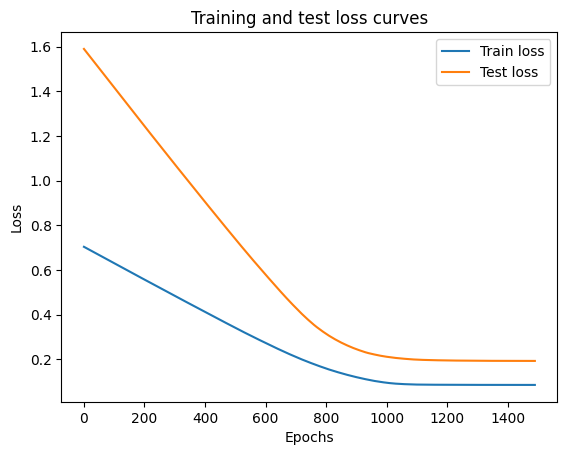

In [14]:
# Plot the loss curves
plt.plot(epoch_count, train_loss_values, label="Train loss")
plt.plot(epoch_count, test_loss_values, label="Test loss")
plt.title("Training and test loss curves")
plt.ylabel("Loss")
plt.xlabel("Epochs")
plt.legend()
plt.show()

In [15]:
# Let's check the updated model parameters after training:

list(model.parameters())

[Parameter containing:
 tensor([0.9919], device='cuda:0', requires_grad=True),
 Parameter containing:
 tensor([-0.0077], device='cuda:0', requires_grad=True)]

To extract the real weight and bias we want, we need to take the following steps:

$$y_{real} = w_{real} * x + b_{real}$$

1. Consider the following equations, that have been used so far:

$$y_{norm} = w_{norm} * x_{norm} + b_{norm}$$
$$y_{norm} = (y_{real} - y_{mean}) / y_{std}$$
$$x_{norm} = (x_{real} - x_{mean}) / x_{std}$$

2. We substitute the second and thrid equations of step 1 in the first equation:

$$(y_{real} - y_{mean}) / y_{std} = w_{norm} * ((x_{real} - x_{mean}) / x_{std}) + b_{norm}$$

3. We multiply both sides by the standart deviation of y:

$$y_{real} - y_{mean} = w_{norm} * (x_{real} - x_{mean}) * (y_{std} / x_{std}) + b_{norm} * y_{std}$$

4. We perform the distributive property:

$$y_{real} - y_{mean} = (w_{norm} * x_{real} * (y_{std} / x_{std})) - (w_{norm} * x_{mean} * (y_{std} / x_{std})) + b_{norm} * y_{std}$$

5. We add the mean of y to both sides:

$$y_{real} = (w_{norm} * (y_{std} / x_{std}) * x_{real}) + b_{norm} * y_{std} + y_{mean} - (w_{norm} * x_{mean} * (y_{std} / x_{std}))$$

6. Comparing the equation of step 5 with our goal:

$$w_{real} = w_{norm} * (y_{std} / x_{std})$$
$$b_{real} = y_{mean} - w_{real} * x_{mean} + b_{norm} * y_{std}$$


In [16]:
w_n = model.weights.item()
b_n = model.bias.item()

real_w = w_n * (y_std / x_std)
real_b = y_mean - real_w * x_mean + b_n * y_std

real_w.item(), real_b.item()

(1.985023021697998, 5.633893013000488)

### Inference

In [17]:
with torch.inference_mode():
    y_pred = model(x_test_n) * y_std + y_mean

y_pred.shape

torch.Size([200, 1])

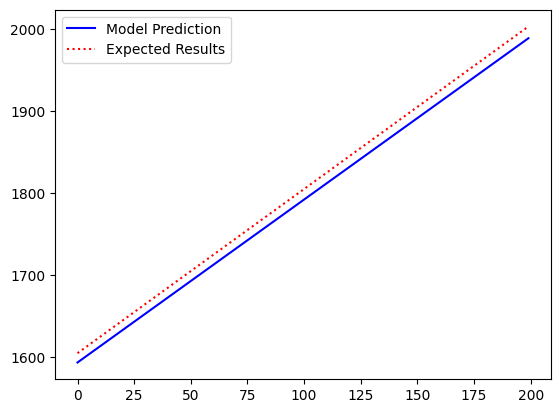

In [18]:
plt.Figure((8, 8))
plt.plot(y_pred.cpu(), "b", label = 'Model Prediction')
plt.plot(answer[train_split:].cpu(), "r:", label = 'Expected Results')
plt.legend()
plt.show()

In [19]:
for i in range(5):
    print(f'Y_pred[{i}]: {y_pred[i]}, answer[{i}]: {answer[train_split - 1 + i]}')  # - 1 in answer because it starts at 0

Y_pred[0]: tensor([1593.6522], device='cuda:0'), answer[0]: 1603.0
Y_pred[1]: tensor([1595.6373], device='cuda:0'), answer[1]: 1605.0
Y_pred[2]: tensor([1597.6223], device='cuda:0'), answer[2]: 1607.0
Y_pred[3]: tensor([1599.6074], device='cuda:0'), answer[3]: 1609.0
Y_pred[4]: tensor([1601.5923], device='cuda:0'), answer[4]: 1611.0


### Saving & Loading the Model

In [20]:
model_dir = Path.cwd().parent / 'trained_models'

model_name_state_dict = "linear_regression_01.pt"
model_name_torch_script = "linear_regression_01_script.pt"

model_path_state_dict = model_dir / model_name_state_dict
model_path_TorchScript = model_dir / model_name_torch_script

#### state_dict

In [21]:
# Save using state_dict(): Recommended, but not portable (needs you to instanciate an object with the class)

torch.save(obj = model.state_dict(), f = model_path_state_dict)

In [22]:
model_loaded = LinearRegressionModel()

model_loaded.load_state_dict(torch.load(model_path_state_dict))

model_loaded.eval()

with torch.inference_mode():
    loaded_model_preds = model_loaded(x_test_n) * y_std + y_mean

loaded_model_preds[:5]

tensor([[1593.6522],
        [1595.6373],
        [1597.6223],
        [1599.6074],
        [1601.5923]], device='cuda:0')

#### TorchScript

In [23]:
# Save using TorchScript: Heavier, more portable -> production ready

scripted = torch.jit.script(model)

scripted.save(model_path_TorchScript)

In [24]:
model_loaded = torch.jit.load(model_path_TorchScript)

model_loaded.eval()

with torch.inference_mode():
    loaded_model_preds = model_loaded(x_test_n) * y_std + y_mean

loaded_model_preds[:5]

tensor([[1593.6522],
        [1595.6373],
        [1597.6223],
        [1599.6074],
        [1601.5923]], device='cuda:0')